<a href="https://colab.research.google.com/github/ryanglenc/MAT_442/blob/main/MAT_442_HW_1_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:

import numpy as np
np.set_printoptions(precision=4, suppress=True)

## 1.3.1 QR Decomposition

Any matrix A with linearly independent columns can be factored as A = QR, where:
- Q has orthonormal columns (Q^T Q = I)
- R is upper triangular

This is essentially Gram–Schmidt in matrix form. We'll compute it with NumPy and verify both properties.

In [6]:
A = np.array([[1, 1, 0],
              [1, 0, 1],
              [0, 1, 1],
              [1, 1, 1]], dtype=float)

Q, R = np.linalg.qr(A)

print("Q (orthonormal columns):\n", Q)
print("\nR (upper triangular):\n", R)

# Verify Q^T Q = I
print("\nQ^T Q (should be identity):\n", Q.T @ Q)

# Verify A = QR
print("\nReconstructed A = QR:\n", Q @ R)
print("Matches original A:", np.allclose(A, Q @ R))

Q (orthonormal columns):
 [[-0.5774  0.2582  0.6761]
 [-0.5774 -0.5164 -0.5071]
 [-0.      0.7746 -0.5071]
 [-0.5774  0.2582 -0.169 ]]

R (upper triangular):
 [[-1.7321 -1.1547 -1.1547]
 [ 0.      1.291   0.5164]
 [ 0.      0.     -1.1832]]

Q^T Q (should be identity):
 [[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0. -0.  1.]]

Reconstructed A = QR:
 [[1. 1. 0.]
 [1. 0. 1.]
 [0. 1. 1.]
 [1. 1. 1.]]
Matches original A: True


## 1.3.2 Least-Squares Problems

When Ax = b has no exact solution (more equations than unknowns, inconsistent system), we instead solve for the x that minimizes ||Ax - b||^2.

The solution satisfies the **normal equations**: A^T A x = A^T b.

We'll solve a small overdetermined system two ways: via the normal equations, and via NumPy's built-in least-squares solver, and confirm they match.

In [7]:
# Overdetermined system: 4 equations, 2 unknowns
A = np.array([[1, 0],
              [1, 1],
              [1, 2],
              [1, 3]], dtype=float)
b = np.array([1, 2, 2, 3], dtype=float)

# Method 1: normal equations
x_normal = np.linalg.inv(A.T @ A) @ A.T @ b
print("Solution via normal equations:", x_normal)

# Method 2: numpy's least-squares solver
x_lstsq, residuals, rank, sv = np.linalg.lstsq(A, b, rcond=None)
print("Solution via np.linalg.lstsq:  ", x_lstsq)

print("\nMatch:", np.allclose(x_normal, x_lstsq))

# Residual norm (how far off Ax is from b)
residual_norm = np.linalg.norm(A @ x_lstsq - b)
print("Residual norm ||Ax - b||:", residual_norm)

Solution via normal equations: [1.1 0.6]
Solution via np.linalg.lstsq:   [1.1 0.6]

Match: True
Residual norm ||Ax - b||: 0.4472135954999579


## 1.3.3 Linear Regression

Simple linear regression fits a line y = β0 + β1*x to data points by minimizing the sum of squared errors — this is exactly a least-squares problem, where A is the "design matrix" with a column of 1s (for the intercept) and a column of x-values.

We'll fit a line to a small dataset and check the fit visually and numerically.

Fitted line: y = 42.27 + 7.11 * x


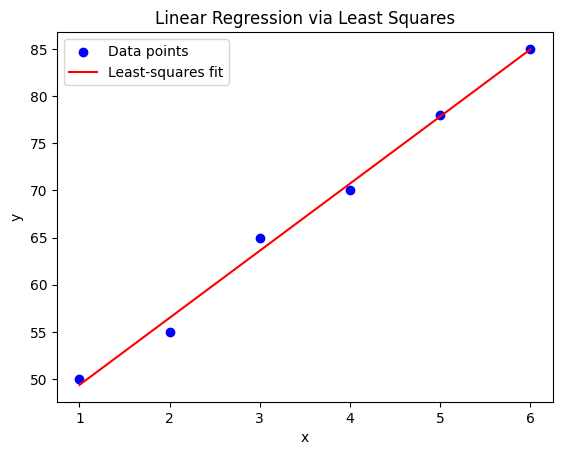

Sum of squared errors: 5.104761904761899


In [8]:
import matplotlib.pyplot as plt

# Sample data (e.g., hours studied vs. exam score)
x = np.array([1, 2, 3, 4, 5, 6])
y = np.array([50, 55, 65, 70, 78, 85])

# Build design matrix: column of 1s (intercept) + x values (slope)
A = np.column_stack((np.ones(len(x)), x))

# Solve least-squares for [intercept, slope]
beta, residuals, rank, sv = np.linalg.lstsq(A, y, rcond=None)
intercept, slope = beta

print(f"Fitted line: y = {intercept:.2f} + {slope:.2f} * x")

# Predicted values
y_pred = A @ beta

# Plot
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label='Least-squares fit')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Linear Regression via Least Squares')
plt.legend()
plt.show()

# Check fit quality: sum of squared residuals
sse = np.sum((y - y_pred) ** 2)
print("Sum of squared errors:", sse)